<a href="https://colab.research.google.com/github/LzJusCodes/LzJusCodes.github.io/blob/main/Palm_Recognition_CSY2082.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# we start by mounting the dataset.

In [ ]:
!ls /content/drive/MyDrive/palm_dataset


palm_1b  palm_2c  palm_3e  palm_4e


In [ ]:
# ======
# We now import the tensorflow library for loading image datasets.
# ======
import tensorflow as tf
import numpy as np


In [ ]:
# =====
# We now define the dataset location
Directory_Data = "/content/drive/MyDrive/palm_dataset"

In [ ]:
# ==================
# Define image and training parameters.
#===================
img_sizing = (128, 128)
batch_sizes = 40
seed = 42

In [ ]:
# It is now time to generate the training dataset.
# We will use the parameter image dataset from directory, this will:
# - open images and assign them with labels
# resize them accordingly
# convert them to grayscale so that it doesn't get confused.
# splits the dataset
dataSet_trainer = tf.keras.utils.image_dataset_from_directory(
    Directory_Data,
    labels="inferred",
    label_mode="int",
    color_mode="grayscale",
    batch_size=batch_sizes,
    image_size=img_sizing, # Resize to IMG_Size
    shuffle=True, # This will make sure we reduce the bias as much as possible.
    seed=seed # ensuring we have a good split that remains somewhat constant.
)

value_ds = tf.keras.utils.image_dataset_from_directory(
    Directory_Data,
    labels="inferred",
    label_mode="int",
    color_mode="grayscale",
    image_size=img_sizing,
    batch_size=batch_sizes,
    shuffle=True,
    seed=seed
)

Found 168 files belonging to 4 classes.
Found 168 files belonging to 4 classes.


In [ ]:
# This next line will allow us to investigate the class labels and
# print out the relational data between folder names and numeric labels.
class_name = dataSet_trainer.class_names
print(class_name)

['palm_1b', 'palm_2c', 'palm_3e', 'palm_4e']


In [ ]:
# Rescaling the images for stability purposes, it's just easier to process from 0-1 than 0 to 255.
normalisation =  tf.keras.layers.Rescaling(1./255)

In [ ]:
dataSet_trainer = dataSet_trainer.map(lambda x, y: (normalisation(x), y), num_parallel_calls=tf.data.AUTOTUNE)
value_ds = value_ds.map(lambda x, y: (normalisation(x), y))

Since the dataset is particularly small, I will utilise data augmentation.
For training purposes only I have opted not to apply it within my piipeline. The reasoning for this is that it can actually affect my validation and give me false positives if I am not careful.

In [ ]:
augmented_data = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
    tf.keras.layers.RandomContrast(0.1),
], name="augmented_data")

Optimising the input pipeline

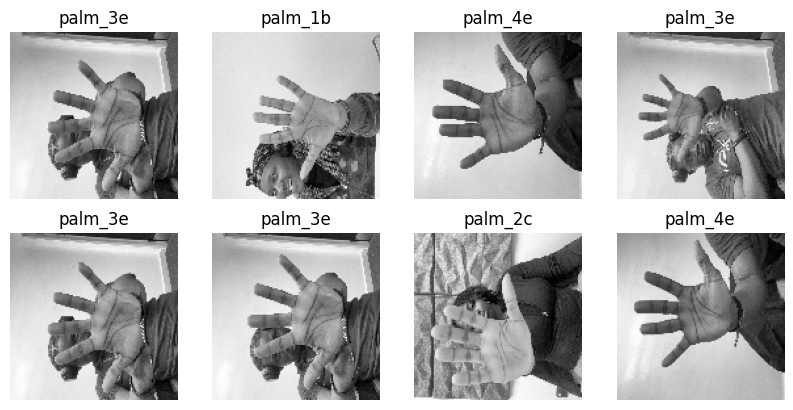

In [ ]:
import matplotlib.pyplot as plt

for images, labels in dataSet_trainer.take(1):
  plt.figure(figsize=(10, 10))
  for i in range(min(8, images.shape[0])):
    ax = plt.subplot(4, 4, i + 1)

    img = images[i].numpy()
    img = np.squeeze(img)

    plt.imshow(img, cmap="gray")
    plt.title(class_name[int(labels[i])])
    plt.axis("off")
plt.show()

We will now proceed to build the fundamentals in order to help the neural network beginning it's training phase. Beginning with the project config.

In [ ]:
cfg = {
    "img_h": 128,
    "img_w": 128,
    "img_c": 1,
    "lr": 8e-4,
    "epochs": 40,
    "dropout":0.35,
    "seed": 42
}

# We will now assume the number of classes from the folders that TensorFlow finds
k_classes = len(class_name)
print("Number of Detected classes is: ", class_name)
print("The overall number of classes is: ", k_classes)

Number of Detected classes is:  ['palm_1b', 'palm_2c', 'palm_3e', 'palm_4e']
The overall number of classes is:  4


In [ ]:
# I am going to attempt to use a mini block function to make my structure a bit more distinct to how others would do it.
# By using conv I can find the local texture; which would be the creasing details in the palm.
# BatchNorm and ReLU will add non-linearity.
def conv_bn_relu(x, filters, k=3, name_prefix="black"):
  x = tf.keras.layers.Conv2D(
      filters, (k, k), padding="same", use_bias=False,
      kernel_initializer="he_normal",
      name=f"{name_prefix}_conv"
  )(x)
  x = tf.keras.layers.BatchNormalization(name=f"{name_prefix}_bn")(x)
  x = tf.keras.layers.Activation("relu", name=f"{name_prefix}_relu")(x)
  return x

Now that is complete, we will now assemble the palm classifier which will be in a functional Application Programming Interface.

This is much more modular in the long run as it makes it easier to expand the code scope later on with extra stuff.

In [ ]:
input = tf.keras.Input(shape=(cfg["img_h"], cfg["img_w"], cfg["img_c"]), name="palm_input")

# Now I will flow the augmentation within the model itself so it only runs during the training phase.
x = augmented_data(input)

# Time to assemble the palm feature extratonator.
x = conv_bn_relu(x, 16, name_prefix="stage1_a")
x = tf.keras.layers.MaxPooling2D(name="stage1_pool")(x)

x = conv_bn_relu(x, 32, name_prefix="stage2_a")
x = tf.keras.layers.MaxPooling2D(name="stage2_pool")(x)

x = conv_bn_relu(x, 64, name_prefix="stage3_a")
x = conv_bn_relu(x, 64, name_prefix="stage3_b")
x = tf.keras.layers.MaxPooling2D(name="stage3_pool")(x)


In [ ]:
# Rather than using a flattening algo which would take tons of parameters to setup,
# we'll just use globalavgpooling

x = tf.keras.layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
x = tf.keras.layers.Dense(128, activation="relu", name="density_128")(x)
x = tf.keras.layers.Dropout(cfg["dropout"], name="dropout")(x)

In [ ]:
# Now in this line will we add an output layer for multi-class classification.
out = tf.keras.layers.Dense(k_classes, activation="softmax", name="class_probabilities")(x)
palm_net = tf.keras.Model(inputs=input, outputs=out, name="palm_net_version1")
palm_net.summary()
#

Model: "palm_net_version1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ palm_input (InputLayer)         │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmented_data (Sequential)     │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_a_conv (Conv2D)          │ (None, 128, 128, 16)   │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_a_bn                     │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_a_relu (Activation)      │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_pool (MaxPooling2D)      │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_a_conv (Conv2D)          │ (None, 64, 64, 32)     │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_a_bn                     │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_a_relu (Activation)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_pool (MaxPooling2D)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage3_a_conv (Conv2D)          │ (None, 32, 32, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage3_a_bn                     │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage3_a_relu (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage3_b_conv (Conv2D)          │ (None, 32, 32, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage3_b_bn                     │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage3_b_relu (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage3_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ density_128 (Dense)             │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probabilities (Dense)     │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,588 (271.83 KB)

 Trainable params: 69,236 (270.45 KB)

 Non-trainable params: 352 (1.38 KB)

In [ ]:
# Finally we are going to train with callbacks. This will reduce the time taken as well as improve the stability as a whole.
cb_early = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

cb_later = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6
)

In [ ]:
# Forgot to compile before using the model. As a result I restarted runtime by accident.
palm_net.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=cfg["lr"]),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)
print("Model Compilation has been successful!")

Model Compilation has been successful!


In [ ]:
# Now where the training begins.

historical_logging = palm_net.fit(
    dataSet_trainer,
    validation_data=value_ds,
    epochs=cfg["epochs"],
    callbacks=[cb_early, cb_later]
)

Epoch 1/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 71s 13s/step - accuracy: 0.2853 - loss: 1.4937 - val_accuracy: 0.2381 - val_loss: 1.5680 - learning_rate: 8.0000e-04
Epoch 2/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 22s 5s/step - accuracy: 0.5700 - loss: 1.1277 - val_accuracy: 0.2381 - val_loss: 1.8389 - learning_rate: 8.0000e-04
Epoch 3/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.6231 - loss: 0.9825 - val_accuracy: 0.2381 - val_loss: 2.3098 - learning_rate: 8.0000e-04
Epoch 4/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 22s 5s/step - accuracy: 0.7731 - loss: 0.7752 - val_accuracy: 0.2381 - val_loss: 2.9255 - learning_rate: 8.0000e-04
Epoch 5/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.8519 - loss: 0.6288 - val_accuracy: 0.2381 - val_loss: 3.5055 - learning_rate: 8.0000e-04
Epoch 6/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 28s 5s/step - accuracy: 0.8695 - loss: 0.6043 - val_accuracy: 0.2381 - val_loss: 3.6015 - learning_rate: 4.0000e-04
Epoch 7/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 35s 4s/step - accuracy: 0.9252 - loss: 0.4981 - val

We will use Matplot in order to plot some curves just to get some reportable evidence in a graphical format. These learning curves will serve as evidence for the training process and how exactly i numbed it down with some slightly unique approaches.

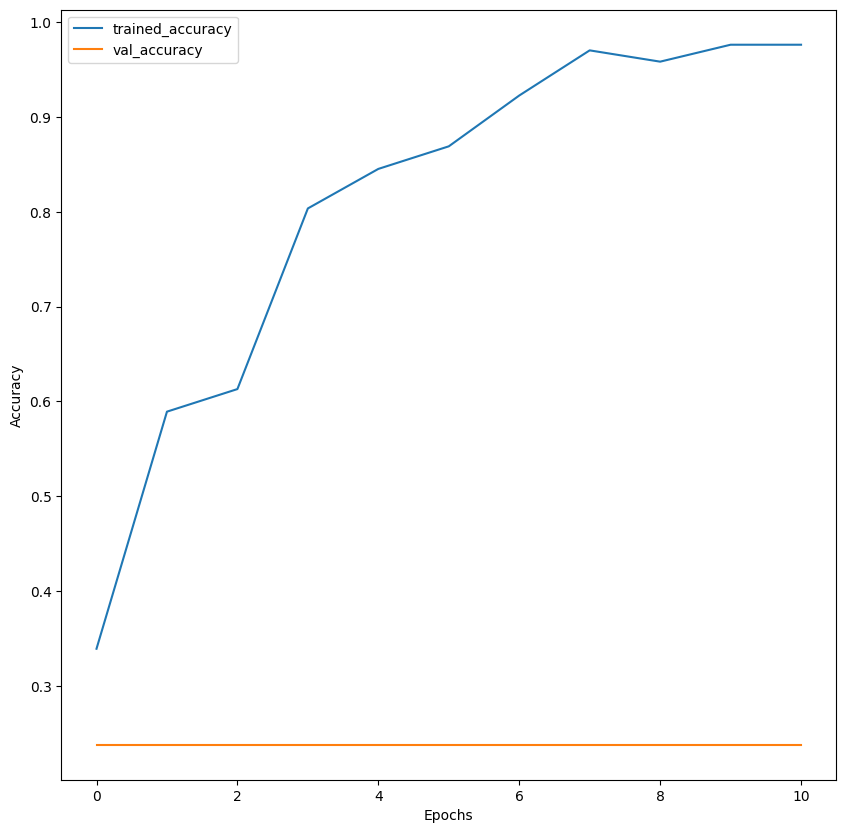

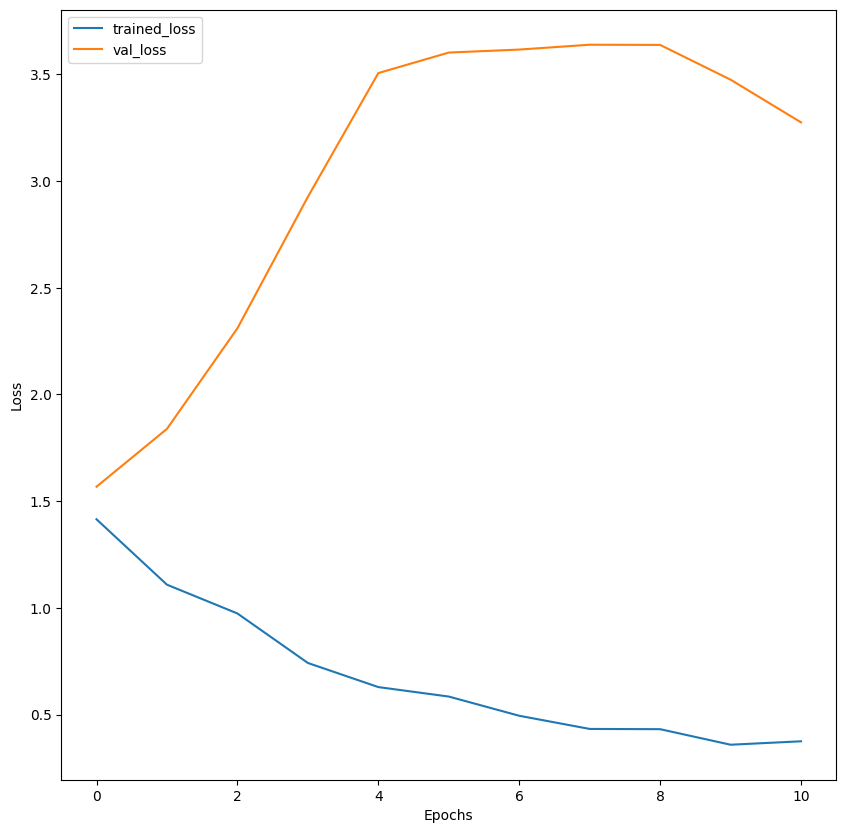

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
plt.plot(historical_logging.history["accuracy"], label="trained_accuracy")
plt.plot(historical_logging.history["val_accuracy"], label="val_accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(10, 10))
plt.plot(historical_logging.history["loss"], label="trained_loss")
plt.plot(historical_logging.history["val_loss"], label="val_loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

All done. In this section the palm recogniser 5000 was trained using the dataset provided. The model was then compiled with what is known as the Adam optimser, combined with a cross loss function sorted categorically and suitable for classification of multiple classes.
I used various precautions such as early stopping to stop the model trying to overfit values and monitor the overal loss in validility across the iterations. I also made sure to adjust the learning rate by using what is known as a reductional allback which essentiially stabilises learning when the overall performance during training stops improving. Efficient data training on a budget dataset!

In [ ]:
# Time for some evaluations.
import numpy as np
y_truth = []
y_predict = []

for x_batch, y_batch in value_ds:
  probs = palm_net.predict(x_batch, verbose=0)
  preds = np.argmax(probs, axis=1)
  y_truth.extend(y_batch.numpy().tolist())

  y_predict.extend(preds.tolist())

y_truth = np.array(y_truth)
y_predict = np.array(y_predict)

print("This is the result on the validation accuracy (manual):", (y_truth == y_predict).mean())

This is the result on the validation accuracy (manual): 0.23809523809523808


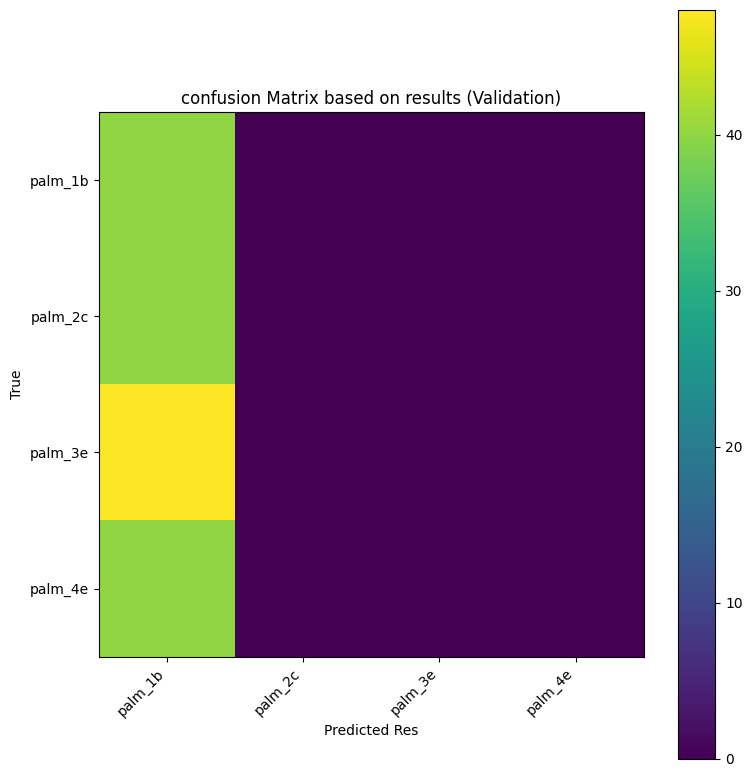

In [ ]:
# Now to try and generate a confusion matrix to compare how many correct and incorrect predictions was made.

import matplotlib.pyplot as plt
import tensorflow as tf

cm = tf.math.confusion_matrix(y_truth, y_predict, num_classes=len(class_name)).numpy()

# plotting it all up.

plt.figure(figsize=(8, 8))

plt.imshow(cm)
plt.title("confusion Matrix based on results (Validation)")
plt.xlabel("Predicted Res")
plt.ylabel("True")
plt.xticks(range(len(class_name)), class_name, rotation=45, ha="right")
plt.yticks(range(len(class_name)), class_name)
plt.colorbar()
plt.tight_layout()
plt.show()

Ok...
So my model failed.
The matrix above shows that the mdel predicts all validations as one singular class. This ddepicts that the mdel has failed to sufficiently differentiate the various features that make up distinctions within each palm classes based on the unseen data provided. The training accuracy increased exponentially but that is quite literally because the validation accuracy remained close to a random chance.  This suggests that despite all the parameters in place, overfitting and low generalisation still occured.
Class collapse tends to happen in machine laerning and it usually happens when the data is limited, and that is essentially what happened here.

# Unknown Palm Handling
This is the part that tackles when an unknown palm from the dataset is shown. This is where more logic needs to be added to account for when something that shouldn't be is shown. By handling ths first before the live demo, it will stop us from just getting a label everytime.

In [ ]:
# Inserting a random unknown variable threshold first for the sole purpose of helping us figure out if one of the models probability is below the threshold.
unknown_thresh = 0.65

In [ ]:
# Now for the predictions when the unknown is presented.
import numpy as np

def unknown_predict(model, image_batch, threshold=unknown_thresh):
  """
Essentially if whatever is returned is greater than the threshold, it returns unknown.
  """
  prob_1 = model.predict(image_batch)
  max_conf = np.max(prob_1, axis=1)
  preds = np.argmax(prob_1, axis=1)

  result = []
  for i in range(len(preds)):
    if max_conf[i] < threshold:
      result.append(("Unknown Variation", float(max_conf[i])))
    else:
      result.append((class_name[preds[i]], float(max_conf[i])))
  return result

Time to test this on my validation samples with unknowns and see?

In [ ]:
for images, labels in value_ds.take(1):
  result = unknown_predict(palm_net, images)
  for i in range(5):
    print(f"Here's the Predictions: {result[i]}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step 
Here's the Predictions: ('Unknown Variation', 0.5319350957870483)
Here's the Predictions: ('Unknown Variation', 0.5427828431129456)
Here's the Predictions: ('Unknown Variation', 0.5461133718490601)
Here's the Predictions: ('Unknown Variation', 0.5114841461181641)
Here's the Predictions: ('Unknown Variation', 0.5370944738388062)


# Camera Demo Section
Not quite sure how to navigate this section. Will most likely use various imports in order to at minimum capture a screenshot that can be worked with.

In [ ]:
!pip -q install opencv-python

import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from base64 import b64decode

In [ ]:
# Decide to go with testing it via my own pc on Visual Studio Code.
palm_net.save("/content/drive/MyDrive/palm_net.keras")

In [ ]:
print(class_name)

['palm_1b', 'palm_2c', 'palm_3e', 'palm_4e']
